# Figure 6 (Standalone) - Intervention Matrix

**Self-contained version for Google Colab** — every function this experiment needs (environments, models, replay buffer, DQN loop, periodic interventions, two-hot head, z-loss, plasticity probe) is defined inline below; there are no imports from the repository's `src/` package. Upload this single file to Colab and run it.

**Colab setup**: `Runtime → Change runtime type → GPU` (a T4 is plenty). All required libraries (torch, torchvision, numpy, pandas, matplotlib, seaborn, tqdm) are preinstalled on Colab.

**What it reproduces**: Section 6.2 of Lyle et al., *Understanding Plasticity in Neural Networks* — the Figure 6 matrix of interventions crossed with architectures. This project's scope: two architectures (**MLP** and **ViT**; the paper's CNN and ResNet18 are dropped to save compute) against the paper's interventions plus one extra of our own, a **z-loss** auxiliary penalty:

- **two_hot** - replace the scalar Q-value head with a categorical (two-hot) distributional head (Farebrother et al.)
- **reset_last_layer** - periodically reinitialize just the output layer
- **weight_decay** - L2 regularization on the optimizer
- **spectral_norm** - constrain every linear/conv layer's spectral norm
- **layernorm** - LayerNorm after each hidden layer
- **shrink_and_perturb** - periodically shrink weights and add fresh-model noise (Ash & Adams)
- **z_loss** *(new)* - penalise the log-partition of the Q-outputs, `coef * (logsumexp(Q(s)))^2`

Each architecture/intervention pair is trained and probed exactly like Figures 3/5, so `plasticity_loss` is directly comparable across figures.

**Session budgeting**: the full matrix is 2 architectures x 8 interventions x 4 seeds = 64 configs. MLP configs are minutes each on a T4; ViT configs are the heavy end — split by architecture or seed using the chunked launch cell at the bottom and merge the CSVs afterwards.

## Setup

Paths are relative to the working directory (`/content` on Colab). Datasets download automatically on first use; results land in `outputs/tables` and `outputs/figures` — download them via Colab's file browser (left sidebar) before the session ends.

In [1]:
import copy
import random
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from collections import deque

ROOT = Path.cwd()
DATA_ROOT = ROOT / "data"
OUTPUT_ROOT = ROOT / "outputs"
FIGURES_DIR = OUTPUT_ROOT / "figures"
TABLES_DIR = OUTPUT_ROOT / "tables"
for directory in (DATA_ROOT, OUTPUT_ROOT, FIGURES_DIR, TABLES_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def _default_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():  # Apple-silicon GPU
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = _default_device()
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

Using device: mps


/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Environments: the Classification MDPs (paper Section 3.2)

MNIST/CIFAR-10 classification recast as a ten-state, ten-action block MDP. A latent state selects a class-conditional image observation; the agent predicts an action in `{0..9}`; the reward rule defines the variant: **easy** (true labels), **hard** (random labels), **sparse** (reward only at state 9 → action 9).

In [2]:
@dataclass(frozen=True)
class ClassificationMDPSpec:
    name: str
    num_states: int = 10
    num_actions: int = 10


class ClassificationMDP:
    def __init__(self, dataset, spec, labels=None, seed=None):
        self.dataset = dataset
        self.spec = spec
        self.rng = random.Random(seed)
        self.labels = labels if labels is not None else self._true_labels(dataset)
        self.class_indices = self._build_class_indices(self.labels)
        self.state = self.rng.randrange(self.spec.num_states)

    @staticmethod
    def _true_labels(dataset):
        targets = getattr(dataset, "targets", None)
        if targets is None:
            return [int(dataset[idx][1]) for idx in range(len(dataset))]
        if isinstance(targets, torch.Tensor):
            return [int(value) for value in targets.tolist()]
        return [int(value) for value in targets]

    def _build_class_indices(self, labels):
        class_indices = {state: [] for state in range(self.spec.num_states)}
        for idx, raw_label in enumerate(labels):
            label = int(raw_label)
            if 0 <= label < self.spec.num_states:
                class_indices[label].append(idx)
        empty = [state for state, indices in class_indices.items() if not indices]
        if empty:
            raise ValueError(f"Every MDP state must have at least one image. Missing states: {empty}")
        return class_indices

    def reset(self, state=None):
        self.state = self.rng.randrange(self.spec.num_states) if state is None else int(state)
        return self.sample_observation(self.state)

    def sample_observation(self, state=None):
        state = self.state if state is None else int(state)
        idx = self.rng.choice(self.class_indices[state])
        image, _ = self.dataset[idx]
        return image

    def transition(self, action):
        raise NotImplementedError

    def step(self, action):
        reward, next_state = self.transition(int(action))
        self.state = int(next_state)
        return self.sample_observation(self.state), float(reward), self.state


def make_random_labels(dataset, num_states=10, seed=None):
    rng = random.Random(seed)
    return [rng.randrange(num_states) for _ in range(len(dataset))]


class EasyMDP(ClassificationMDP):
    def __init__(self, dataset, seed=None):
        super().__init__(dataset, ClassificationMDPSpec(name="easy"), seed=seed)

    def transition(self, action):
        reward = float(int(action) == int(self.state))
        self.state = self.rng.randrange(self.spec.num_states)
        return reward, self.state


class HardMDP(ClassificationMDP):
    def __init__(self, dataset, seed=None):
        labels = make_random_labels(dataset, seed=seed)
        super().__init__(dataset, ClassificationMDPSpec(name="hard"), labels=labels, seed=seed)

    def transition(self, action):
        reward = float(int(action) == int(self.state))
        self.state = self.rng.randrange(self.spec.num_states)
        return reward, self.state


class SparseMDP(ClassificationMDP):
    def __init__(self, dataset, seed=None):
        super().__init__(dataset, ClassificationMDPSpec(name="sparse"), seed=seed)

    def transition(self, action):
        action_matches_state = int(action) == int(self.state)
        reward = float(action_matches_state and int(self.state) == 9)
        if action_matches_state:
            next_state = (int(self.state) + 1) % self.spec.num_states
        else:
            next_state = self.rng.randrange(self.spec.num_states)
        self.state = next_state
        return reward, next_state

## Models (paper Appendix A.2)

The **MLP** (two hidden ReLU layers) and the paper's small **ViT** (conv patch embedding with patch size 3, model dim 256, one transformer block, feedforward width 1024, dropout 0.1, trained from scratch). Both take a configurable `output_dim` (the two-hot head needs `10 * bins` outputs) and expose `last_layer` / `reset_last_layer()` for the reset intervention.

In [3]:
def _prod(values):
    out = 1
    for v in values:
        out *= int(v)
    return out


def _maybe_spectral_norm(module, enabled):
    return nn.utils.spectral_norm(module) if enabled else module


class MLP(nn.Module):
    def __init__(self, input_shape=(1, 28, 28), output_dim=10, hidden_dim=512,
                 use_layernorm=False, spectral_norm=False):
        super().__init__()
        self.input_dim = _prod(input_shape)
        self.hidden_dim = int(hidden_dim)
        self.output_dim = int(output_dim)
        self.feature_dim = self.hidden_dim

        self.fc1 = _maybe_spectral_norm(nn.Linear(self.input_dim, self.hidden_dim), spectral_norm)
        self.fc2 = _maybe_spectral_norm(nn.Linear(self.hidden_dim, self.hidden_dim), spectral_norm)
        self.output = nn.Linear(self.hidden_dim, self.output_dim)

        self.ln1 = nn.LayerNorm(self.hidden_dim) if use_layernorm else nn.Identity()
        self.ln2 = nn.LayerNorm(self.hidden_dim) if use_layernorm else nn.Identity()
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()

    @property
    def last_layer(self):
        return self.output

    def reset_last_layer(self):
        self.output.reset_parameters()

    def forward_features(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu1(self.ln1(self.fc1(x)))
        x = self.relu2(self.ln2(self.fc2(x)))
        return x

    def forward(self, x):
        return self.output(self.forward_features(x))


class VisionTransformer(nn.Module):
    def __init__(self, input_shape=(1, 28, 28), output_dim=10, patch_size=3,
                 dim=256, depth=1, heads=4, mlp_dim=1024, dropout=0.1):
        super().__init__()
        channels, image_size = int(input_shape[0]), int(input_shape[1])
        self.patch_size = int(patch_size)
        self.output_dim = int(output_dim)
        self.feature_dim = int(dim)

        self.patch_embedding = nn.Conv2d(channels, dim, kernel_size=patch_size, stride=patch_size)

        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            embedded = self.patch_embedding(dummy)
            num_patches = embedded.shape[-2] * embedded.shape[-1]

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=mlp_dim,
            dropout=dropout, activation="gelu", batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, dim))
        self.dropout = nn.Dropout(dropout)

        self.mlp_head = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, self.output_dim))

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

    @property
    def last_layer(self):
        return self.mlp_head[-1]

    def reset_last_layer(self):
        self.mlp_head[-1].reset_parameters()

    def forward_features(self, x):
        x = self.patch_embedding(x)
        x = x.flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embedding[:, : x.size(1)]
        x = self.dropout(x)
        x = self.transformer(x)
        return x[:, 0]

    def forward(self, x):
        return self.mlp_head(self.forward_features(x))

## Replay Buffer

In [4]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = deque(maxlen=capacity)
        self.device = DEVICE

    def push(self, image, action, reward, next_image):
        self.buffer.append((image, action, reward, next_image))

    def sample(self, batch_size, device=None):
        device = self.device if device is None else device
        batch = random.sample(self.buffer, batch_size)
        images, actions, rewards, next_images = zip(*batch)
        return (
            torch.tensor(np.array(images), dtype=torch.float32, device=device),
            torch.tensor(actions, dtype=torch.long, device=device),
            torch.tensor(rewards, dtype=torch.float32, device=device),
            torch.tensor(np.array(next_images), dtype=torch.float32, device=device),
        )

    def sample_states(self, batch_size, device=None):
        device = self.device if device is None else device
        batch = random.sample(self.buffer, min(batch_size, len(self.buffer)))
        images = [item[0] for item in batch]
        return torch.tensor(np.array(images), dtype=torch.float32, device=device)

    def __len__(self):
        return len(self.buffer)

## DQN Machinery + Periodic Interventions

The shared config and training-step functions, plus the two periodic interventions that operate on the parameters directly: `reset_last_layer` reinitializes the output layer every `reset_last_layer_every` steps, and `shrink_and_perturb` blends every float parameter toward a freshly initialized model (`shrink * theta + perturb * theta_fresh`) every `shrink_perturb_every` steps.

In [5]:
@dataclass
class ClassificationDQNConfig:
    seed: int = 0
    data_root: str = "./data"
    download: bool = True
    observation_space: str = "mnist"
    environment: str = "easy"
    architecture: str = "mlp"
    hidden_dim: int = 512
    gamma: float = 0.99
    lr: float = 1e-3
    optimizer: str = "adam"
    weight_decay: float = 0.0
    batch_size: int = 512
    replay_capacity: int = 50_000
    warmup_steps: int = 2_000
    train_steps: int = 20_000
    target_update_period: int = 1_000
    epsilon_start: float = 1.0
    epsilon_final: float = 0.01
    epsilon_decay: int = 10_000
    use_layernorm: bool = False
    spectral_norm: bool = False
    shrink_perturb_every: Optional[int] = None
    shrink: float = 0.4
    perturb: float = 0.1
    reset_last_layer_every: Optional[int] = None


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_dataset(config):
    if config.observation_space == "mnist":
        dataset = datasets.MNIST(root=str(config.data_root), train=True,
                                 download=config.download, transform=transforms.ToTensor())
        input_shape = (1, 28, 28)
    elif config.observation_space == "cifar10":
        dataset = datasets.CIFAR10(root=str(config.data_root), train=True,
                                   download=config.download, transform=transforms.ToTensor())
        input_shape = (3, 32, 32)
    else:
        raise ValueError(f"Unknown observation space: {config.observation_space}")
    return dataset, input_shape


def build_environment(config, dataset):
    if config.environment == "easy":
        return EasyMDP(dataset, seed=config.seed)
    if config.environment == "hard":
        return HardMDP(dataset, seed=config.seed)
    if config.environment == "sparse":
        return SparseMDP(dataset, seed=config.seed)
    raise ValueError(f"Unknown environment: {config.environment}")


def build_optimizer(config, model):
    if config.optimizer == "adam":
        return torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    if config.optimizer == "sgd":
        return torch.optim.SGD(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    raise ValueError(f"Unknown optimizer: {config.optimizer}")


def optimizer_factory_from_config(config):
    def factory(model):
        return build_optimizer(config, model)
    return factory


def epsilon_at_step(config, step):
    return config.epsilon_final + (config.epsilon_start - config.epsilon_final) * np.exp(
        -float(step) / float(config.epsilon_decay)
    )


@torch.no_grad()
def select_action(model, observation, epsilon, device=None):
    device = DEVICE if device is None else device
    if random.random() < epsilon:
        return random.randrange(10)
    q_values = model(observation.unsqueeze(0).to(device))
    return int(q_values.argmax(dim=1).item())


def collect_transition(env, model, replay, epsilon, device=None):
    observation = env.sample_observation()
    action = select_action(model, observation, epsilon, device=device)
    next_observation, reward, _ = env.step(action)
    replay.push(observation, action, reward, next_observation)


def dqn_loss(model, target_model, batch, gamma):
    states, actions, rewards, next_states = batch
    q_sa = model(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        next_q = target_model(next_states).max(dim=1).values
        target = rewards + gamma * next_q
    return F.mse_loss(q_sa, target)


def train_dqn_step(model, target_model, optimizer, replay, config, device=None):
    device = DEVICE if device is None else device
    batch = replay.sample(config.batch_size, device=device)
    loss = dqn_loss(model, target_model, batch, config.gamma)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    return float(loss.detach().cpu().item())


@torch.no_grad()
def shrink_and_perturb(model, fresh_model, shrink, perturb):
    fresh_state = fresh_model.state_dict()
    current_state = model.state_dict()
    for name, value in current_state.items():
        if torch.is_floating_point(value):
            value.mul_(shrink).add_(fresh_state[name].to(value.device), alpha=perturb)


def maybe_apply_periodic_interventions(model, model_factory, config, step, device=None):
    device = DEVICE if device is None else device
    if config.reset_last_layer_every and step % config.reset_last_layer_every == 0:
        if hasattr(model, "reset_last_layer"):
            model.reset_last_layer()

    if config.shrink_perturb_every and step % config.shrink_perturb_every == 0:
        fresh_model = model_factory().to(device)
        shrink_and_perturb(model, fresh_model, config.shrink, config.perturb)

## Plasticity Probe (paper Sections 2.2 / 3.1)

The random-target probe: from a copy of the current parameters, fit `num_tasks` fresh random regression targets (`offset + sin(1e5 * f_random(x))`) for `steps` optimizer steps. `measure_plasticity_loss` compares the trained network's probe loss against the untrained baseline; the difference is the plasticity loss.

In [6]:
@dataclass
class PlasticityProbeConfig:
    steps: int = 2000
    num_tasks: int = 10
    batch_size: Optional[int] = None
    target_scale: float = 1e5


@dataclass
class ProbeTaskResult:
    initial_loss: float
    final_loss: float


@dataclass
class PlasticityResult:
    probe_loss: float
    baseline_probe_loss: Optional[float]
    plasticity_loss: Optional[float]
    task_losses: List[float]
    baseline_task_losses: Optional[List[float]]


def _device_of(model):
    return next(model.parameters()).device


def _sample_indices(inputs, batch_size):
    if batch_size is None or batch_size >= inputs.size(0):
        return None
    return torch.randint(0, inputs.size(0), (batch_size,), device=inputs.device)


@torch.no_grad()
def make_random_function_targets(model, random_model, inputs, target_scale=1e5):
    model.eval()
    random_model.eval()
    inputs = inputs.to(_device_of(model))
    random_model = random_model.to(inputs.device)
    offset = model(inputs).mean(dim=0, keepdim=True)
    random_outputs = random_model(inputs)
    return (offset + torch.sin(target_scale * random_outputs)).detach()


def train_probe_task(model, inputs, targets, optimizer_factory, config, progress_desc=None):
    probe_model = copy.deepcopy(model).to(_device_of(model))
    inputs = inputs.to(_device_of(probe_model))
    targets = targets.to(_device_of(probe_model))
    optimizer = optimizer_factory(probe_model)

    with torch.no_grad():
        initial_loss = float(F.mse_loss(probe_model(inputs), targets).cpu().item())

    probe_model.train()
    step_iter = tqdm(range(1, config.steps + 1), desc=progress_desc, unit="step",
                     leave=False, disable=progress_desc is None)
    for step in step_iter:
        indices = _sample_indices(inputs, config.batch_size)
        if indices is None:
            batch_inputs, batch_targets = inputs, targets
        else:
            batch_inputs = inputs.index_select(0, indices)
            batch_targets = targets.index_select(0, indices)

        loss = F.mse_loss(probe_model(batch_inputs), batch_targets)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if progress_desc is not None and step % 50 == 0:
            step_iter.set_postfix(loss=f"{float(loss.detach().cpu()):.4f}")

    with torch.no_grad():
        final_loss = float(F.mse_loss(probe_model(inputs), targets).cpu().item())

    return ProbeTaskResult(initial_loss=initial_loss, final_loss=final_loss)


def run_random_probe_task(model, random_model_factory, inputs, optimizer_factory, config, progress_desc=None):
    random_model = random_model_factory().to(_device_of(model))
    targets = make_random_function_targets(model, random_model, inputs, target_scale=config.target_scale)
    return train_probe_task(model, inputs, targets, optimizer_factory, config, progress_desc=progress_desc)


def estimate_probe_loss(model, random_model_factory, inputs, optimizer_factory, config, desc=None):
    return [
        run_random_probe_task(
            model, random_model_factory, inputs, optimizer_factory, config,
            progress_desc=None if desc is None else f"{desc} [task {task + 1}/{config.num_tasks}]",
        )
        for task in range(config.num_tasks)
    ]


def measure_plasticity_loss(model, random_model_factory, inputs, optimizer_factory, config,
                            baseline_model=None, desc=None):
    task_results = estimate_probe_loss(
        model, random_model_factory, inputs, optimizer_factory, config,
        desc=None if desc is None else f"{desc} (trained)",
    )
    task_losses = [result.final_loss for result in task_results]
    probe_loss = float(np.mean(task_losses))

    baseline_task_losses = None
    baseline_probe_loss = None
    if baseline_model is not None:
        baseline_results = estimate_probe_loss(
            baseline_model, random_model_factory, inputs, optimizer_factory, config,
            desc=None if desc is None else f"{desc} (initial)",
        )
        baseline_task_losses = [result.final_loss for result in baseline_results]
        baseline_probe_loss = float(np.mean(baseline_task_losses))

    plasticity_loss = None if baseline_probe_loss is None else float(probe_loss - baseline_probe_loss)

    return PlasticityResult(
        probe_loss=probe_loss,
        baseline_probe_loss=baseline_probe_loss,
        plasticity_loss=plasticity_loss,
        task_losses=task_losses,
        baseline_task_losses=baseline_task_losses,
    )

## Run Configuration

`InterventionRunConfig` adds which `intervention` to apply, the z-loss coefficient, and the two-hot head's bin count/value range. `configure_intervention` maps an intervention name onto the right combination of config fields (e.g. `"weight_decay"` just sets `weight_decay=1e-4`; `"two_hot"` and `"z_loss"` don't change any shared-loop field — they're handled by their own training paths below).

In [7]:
INTERVENTIONS = (
    "neither",
    "two_hot",
    "reset_last_layer",
    "weight_decay",
    "spectral_norm",
    "layernorm",
    "shrink_and_perturb",
    "z_loss",
)


@dataclass
class InterventionRunConfig(ClassificationDQNConfig):
    intervention: str = "neither"
    z_loss_coef: float = 1e-4
    two_hot_bins: int = 51
    two_hot_min: float = -100.0
    two_hot_max: float = 100.0
    probe_steps: int = 2_000
    num_probe_tasks: int = 10
    probe_batch_size: int = 256


def configure_intervention(base, intervention):
    if intervention not in INTERVENTIONS:
        raise ValueError(f"Unknown intervention: {intervention}")

    config = replace(
        base,
        intervention=intervention,
        use_layernorm=False,
        spectral_norm=False,
        weight_decay=0.0,
        reset_last_layer_every=None,
        shrink_perturb_every=None,
    )
    if intervention == "weight_decay":
        return replace(config, weight_decay=1e-4)
    if intervention == "spectral_norm":
        return replace(config, spectral_norm=True)
    if intervention == "layernorm":
        return replace(config, use_layernorm=True)
    if intervention == "reset_last_layer":
        return replace(config, reset_last_layer_every=config.target_update_period)
    if intervention == "shrink_and_perturb":
        return replace(config, shrink_perturb_every=config.target_update_period)
    return config

## Model Factory

Two architectures: MLP and ViT. Every architecture is available for every intervention except `two_hot`, which needs `10 * two_hot_bins` output units (one categorical distribution per action) instead of 10 scalar Q-values. The MLP applies spectral norm at construction; the ViT gets it applied recursively afterwards (its layers live inside the transformer block).

In [8]:
def apply_spectral_normalization(module):
    for name, child in module.named_children():
        if isinstance(child, (nn.Linear, nn.Conv2d)):
            setattr(module, name, nn.utils.spectral_norm(child))
        else:
            apply_spectral_normalization(child)
    return module


def build_intervention_model_factory(config, input_shape):
    output_dim = 10 * config.two_hot_bins if config.intervention == "two_hot" else 10

    def factory():
        if config.architecture == "mlp":
            model = MLP(
                input_shape=input_shape,
                output_dim=output_dim,
                hidden_dim=config.hidden_dim,
                use_layernorm=config.use_layernorm,
                spectral_norm=config.spectral_norm,
            )
        elif config.architecture == "vit":
            model = VisionTransformer(
                input_shape=input_shape,
                output_dim=output_dim,
                patch_size=3,
                dim=256,
                depth=1,
                mlp_dim=1024,
                dropout=0.1,
            )
        else:
            raise ValueError(f"Unknown architecture: {config.architecture}")

        if config.spectral_norm and config.architecture == "vit":
            model = apply_spectral_normalization(model)
        return model

    return factory

## Two-Hot Distributional Head

Following Farebrother et al., each action's scalar Q-value is replaced by a categorical distribution over `two_hot_bins` fixed support values between `two_hot_min` and `two_hot_max`. `encode` turns a scalar target into a two-hot distribution (weight split between the two nearest bins); `expected_value` turns a predicted distribution back into a scalar for action selection.

In [9]:
class TwoHotEncoding:
    def __init__(self, bins=51, vmin=-10.0, vmax=10.0, device=DEVICE):
        self.bins = int(bins)
        self.vmin = float(vmin)
        self.vmax = float(vmax)
        self.support = torch.linspace(vmin, vmax, bins, device=device)

    def to(self, device):
        self.support = self.support.to(device)
        return self

    def encode(self, values):
        values = values.clamp(self.vmin, self.vmax)
        position = (values - self.vmin) / (self.vmax - self.vmin) * (self.bins - 1)
        lower = torch.floor(position).long().clamp(0, self.bins - 1)
        upper = torch.ceil(position).long().clamp(0, self.bins - 1)
        upper_weight = position - lower.float()
        lower_weight = 1.0 - upper_weight

        distribution = torch.zeros(*values.shape, self.bins, device=values.device)
        distribution.scatter_add_(-1, lower.unsqueeze(-1), lower_weight.unsqueeze(-1))
        distribution.scatter_add_(-1, upper.unsqueeze(-1), upper_weight.unsqueeze(-1))
        return distribution

    def expected_value(self, logits):
        probs = torch.softmax(logits, dim=-1)
        return (probs * self.support.to(logits.device)).sum(dim=-1)


@torch.no_grad()
def select_two_hot_action(model, observation, encoding, epsilon, device=DEVICE):
    if random.random() < epsilon:
        return random.randrange(10)
    logits = model(observation.unsqueeze(0).to(device)).view(1, 10, encoding.bins)
    q_values = encoding.expected_value(logits)
    return int(q_values.argmax(dim=1).item())


def collect_two_hot_transition(env, model, replay, encoding, epsilon, device=DEVICE):
    observation = env.sample_observation()
    action = select_two_hot_action(model, observation, encoding, epsilon, device=device)
    next_observation, reward, _ = env.step(action)
    replay.push(observation, action, reward, next_observation)


def two_hot_dqn_loss(model, target_model, batch, gamma, encoding):
    states, actions, rewards, next_states = batch
    logits = model(states).view(states.size(0), 10, encoding.bins)
    chosen_logits = logits.gather(
        1, actions.view(-1, 1, 1).expand(-1, 1, encoding.bins)
    ).squeeze(1)

    with torch.no_grad():
        next_logits = target_model(next_states).view(next_states.size(0), 10, encoding.bins)
        next_q = encoding.expected_value(next_logits).max(dim=1).values
        target_values = rewards + gamma * next_q
        target_distribution = encoding.encode(target_values)

    log_probs = F.log_softmax(chosen_logits, dim=-1)
    return -(target_distribution * log_probs).sum(dim=-1).mean()


def train_two_hot_step(model, target_model, optimizer, replay, config, encoding, device=DEVICE):
    batch = replay.sample(config.batch_size, device=device)
    loss = two_hot_dqn_loss(model, target_model, batch, config.gamma, encoding)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    return float(loss.detach().cpu().item())

## z-loss Auxiliary Penalty (new intervention)

An intervention beyond the paper's set: a **z-loss** term added to the standard Q-learning objective. z-loss penalises the log-partition function of the output logits -- `(logsumexp(Q(s)))^2` -- pulling the softmax normaliser toward one and so keeping the absolute scale of the outputs bounded. It originates in large-model training (PaLM; Wortsman et al., 2023) as a stability regulariser.

The regression DQN head has no softmax, so here the ten Q-values play the role of logits: bounding their log-partition bounds their scale, which is the same loss-landscape-smoothing mechanism the other interventions target. It is applied as a plain auxiliary term on the standard head (output dim 10), so it slots into the matrix as its own column, directly comparable to layernorm, spectral norm, and the rest. A single forward pass feeds both the TD loss and the z-loss.

In [10]:
def train_dqn_zloss_step(model, target_model, optimizer, replay, config, device=DEVICE):
    states, actions, rewards, next_states = replay.sample(config.batch_size, device=device)

    logits = model(states)  # (batch, 10): the Q-values, treated as logits
    q_sa = logits.gather(1, actions.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        next_q = target_model(next_states).max(dim=1).values
        target = rewards + config.gamma * next_q
    td_loss = F.mse_loss(q_sa, target)

    # z-loss: penalise the log-partition of the output logits so the Q-value
    # scale stays bounded. Shares the forward pass above -- no extra compute.
    log_partition = torch.logsumexp(logits, dim=-1)
    z_loss = config.z_loss_coef * log_partition.pow(2).mean()

    loss = td_loss + z_loss
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    return float(loss.detach().cpu().item())

## Training + Probing per Intervention

`run_intervention_config` trains one architecture/intervention pair. It branches on the intervention: `two_hot` uses the distributional collect/train functions, `z_loss` uses the auxiliary-penalty step, and everything else reuses the shared `collect_transition`/`train_dqn_step` loop plus `maybe_apply_periodic_interventions` (last-layer resets and shrink-and-perturb driven by the config fields `configure_intervention` set). After training, the plasticity probe compares the trained network against its own untrained copy.

In [11]:
def run_intervention_config(config):
    label = f"{config.architecture}/{config.intervention} seed{config.seed}"
    set_seed(config.seed)
    dataset, input_shape = load_dataset(config)
    env = build_environment(config, dataset)
    model_factory = build_intervention_model_factory(config, input_shape)
    model = model_factory().to(DEVICE)
    initial_model = copy.deepcopy(model).to(DEVICE)
    target_model = copy.deepcopy(model).to(DEVICE)
    optimizer = build_optimizer(config, model)
    replay = ReplayBuffer(config.replay_capacity)
    encoding = TwoHotEncoding(config.two_hot_bins, config.two_hot_min, config.two_hot_max, DEVICE)

    for _ in tqdm(range(config.warmup_steps), desc="warmup", unit="step", leave=False):
        if config.intervention == "two_hot":
            collect_two_hot_transition(env, model, replay, encoding, epsilon=1.0, device=DEVICE)
        else:
            collect_transition(env, model, replay, epsilon=1.0, device=DEVICE)

    last_loss = float("nan")
    train_bar = tqdm(range(1, config.train_steps + 1), desc=f"train {label}", unit="step")
    for step in train_bar:
        epsilon = epsilon_at_step(config, step)
        if config.intervention == "two_hot":
            collect_two_hot_transition(env, model, replay, encoding, epsilon, device=DEVICE)
            last_loss = train_two_hot_step(
                model, target_model, optimizer, replay, config, encoding, device=DEVICE,
            )
        elif config.intervention == "z_loss":
            collect_transition(env, model, replay, epsilon, device=DEVICE)
            last_loss = train_dqn_zloss_step(
                model, target_model, optimizer, replay, config, device=DEVICE,
            )
        else:
            collect_transition(env, model, replay, epsilon, device=DEVICE)
            last_loss = train_dqn_step(model, target_model, optimizer, replay, config, device=DEVICE)

        maybe_apply_periodic_interventions(model, model_factory, config, step, device=DEVICE)

        if step % 100 == 0:
            train_bar.set_postfix(loss=f"{last_loss:.4f}", eps=f"{epsilon:.2f}")

        if step % config.target_update_period == 0:
            target_model.load_state_dict(model.state_dict())
    train_bar.close()

    inputs = replay.sample_states(config.probe_batch_size, device=DEVICE)
    probe_config = PlasticityProbeConfig(
        steps=config.probe_steps, num_tasks=config.num_probe_tasks, batch_size=config.probe_batch_size,
    )
    result = measure_plasticity_loss(
        model, model_factory, inputs, optimizer_factory_from_config(config), probe_config,
        baseline_model=initial_model, desc=f"probe {label}",
    )

    return {
        "seed": config.seed,
        "observation_space": config.observation_space,
        "environment": config.environment,
        "architecture": config.architecture,
        "intervention": config.intervention,
        "probe_loss": result.probe_loss,
        "initial_probe_loss": result.baseline_probe_loss,
        "plasticity_loss": result.plasticity_loss,
        "last_training_loss": last_loss,
    }


def run_intervention_matrix(configs, save_path=None):
    rows = []
    sweep_start = time.perf_counter()
    for idx, config in enumerate(configs, start=1):
        print(f"[{idx}/{len(configs)}] {config.architecture}/{config.intervention} seed{config.seed}")
        config_start = time.perf_counter()
        rows.append(run_intervention_config(config))
        row = rows[-1]
        config_min = (time.perf_counter() - config_start) / 60
        elapsed_min = (time.perf_counter() - sweep_start) / 60
        remaining_min = elapsed_min / idx * (len(configs) - idx)
        print(f"[{idx}/{len(configs)}] plasticity_loss={row['plasticity_loss']:+.4f} | "
              f"done in {config_min:.1f} min | elapsed {elapsed_min:.1f} min | "
              f"est. remaining {remaining_min:.0f} min")
    df = pd.DataFrame(rows)
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_path, index=False)
        print(f"Saved intervention matrix table to {save_path}")
    return df

## Smoke vs. Paper-Scale Configs

`make_smoke_configs` runs 5 cheap combinations in a few minutes (MLP with several interventions plus one ViT sanity check). `make_intervention_matrix_configs` builds the full matrix: both architectures crossed with every intervention, including the new `z_loss`.

In [12]:
def make_intervention_matrix_configs(
    data_root="./data",
    download=True,
    architectures=("mlp", "vit"),
    interventions=INTERVENTIONS,
    environment="easy",
    observation_space="mnist",
    seeds=(0,),
):
    base = InterventionRunConfig(
        data_root=data_root,
        download=download,
        observation_space=observation_space,
        environment=environment,
        hidden_dim=512,
        batch_size=256,
        replay_capacity=5_000,
        warmup_steps=2_000,
        train_steps=100_000,
        target_update_period=1_000,
        probe_steps=2_000,
        num_probe_tasks=10,
        probe_batch_size=256,
    )
    configs = []
    for seed in seeds:
        for architecture in architectures:
            for intervention in interventions:
                configs.append(
                    configure_intervention(replace(base, seed=seed, architecture=architecture), intervention)
                )
    return configs


def make_smoke_configs(data_root="./data", download=True):
    base = InterventionRunConfig(
        data_root=data_root,
        download=download,
        observation_space="mnist",
        environment="easy",
        hidden_dim=128,
        batch_size=128,
        replay_capacity=5_000,
        warmup_steps=512,
        train_steps=1_000,
        target_update_period=250,
        probe_steps=50,
        num_probe_tasks=2,
        probe_batch_size=128,
        two_hot_bins=21,
    )
    return [
        configure_intervention(replace(base, architecture="mlp"), "neither"),
        # configure_intervention(replace(base, architecture="mlp"), "layernorm"),
        # configure_intervention(replace(base, architecture="mlp"), "two_hot"),
        # configure_intervention(replace(base, architecture="mlp"), "z_loss"),
        # configure_intervention(replace(base, architecture="mlp"), "reset_last_layer"),
        # configure_intervention(replace(base, architecture="mlp"), "weight_decay"),
        # configure_intervention(replace(base, architecture="mlp"), "spectral_norm"),
        # configure_intervention(replace(base, architecture="mlp"), "shrink_and_perturb"),
        # configure_intervention(replace(base, architecture="vit"), "neither"),
        # configure_intervention(replace(base, architecture="vit"), "layernorm"),
        # configure_intervention(replace(base, architecture="vit"), "two_hot"),
        # configure_intervention(replace(base, architecture="vit"), "z_loss"),
        # configure_intervention(replace(base, architecture="vit"), "reset_last_layer"),
        # configure_intervention(replace(base, architecture="vit"), "weight_decay"),
        # configure_intervention(replace(base, architecture="vit"), "spectral_norm"),
        # configure_intervention(replace(base, architecture="vit"), "shrink_and_perturb")
    ]

## Smoke Run (fast sanity check)

In [13]:
smoke_df = run_intervention_matrix(
    make_smoke_configs(data_root=str(DATA_ROOT)),
    save_path=TABLES_DIR / "figure6_smoke.csv",
)
smoke_df

[1/1] mlp/neither seed0


train mlp/neither seed0: 100%|██████████| 1000/1000 [00:04<00:00, 202.48step/s, eps=0.91, loss=0.0195]
                                                                                                   

[1/1] plasticity_loss=+0.0903 | done in 0.1 min | elapsed 0.1 min | est. remaining 0 min
Saved intervention matrix table to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/notebooks/outputs/tables/figure6_smoke.csv


,seed,observation_space,environment,architecture,intervention,probe_loss,initial_probe_loss,plasticity_loss,last_training_loss
0,0,mnist,easy,mlp,neither,0.132078,0.041737,0.090341,0.019466


## Chunked Paper-Scale Run

The full matrix is 2 architectures x 8 interventions x 4 seeds = 64 configs. Every config is independent — split along any axis (architecture is the natural one: ViT configs are the expensive end) and merge the CSVs afterwards. Edit the filter and **give each chunk a distinct `save_path`**.

In [ ]:
full_configs = make_intervention_matrix_configs(
    data_root=str(DATA_ROOT),
    seeds=(0, 12, 20, 42),
)
print(f"total paper configs: {len(full_configs)}")

# EDIT THIS FILTER for the current session's chunk, e.g.:
#   chunk = [c for c in full_configs if c.architecture == "vit"]
#   chunk = [c for c in full_configs if c.seed == 0]
chunk = [c for c in full_configs if c.architecture == "mlp" and (c.seed == 20 or c.seed == 42)]
chunk_name = "mlp_seed20_42"  # EDIT: used in the output filename

print(f"this session runs {len(chunk)} configs")

# Uncomment to launch:
chunk_df = run_intervention_matrix(chunk, save_path=TABLES_DIR / f"figure6_chunk_{chunk_name}.csv")

total paper configs: 64
this session runs 16 configs
[1/16] mlp/neither seed20


train mlp/neither seed20: 100%|██████████| 100000/100000 [11:31<00:00, 144.63step/s, eps=0.01, loss=0.0693]


[1/16] plasticity_loss=+0.0312 | done in 12.1 min | elapsed 12.1 min | est. remaining 182 min
[2/16] mlp/two_hot seed20


train mlp/two_hot seed20: 100%|██████████| 100000/100000 [19:59<00:00, 83.36step/s, eps=0.01, loss=0.3263]


[2/16] plasticity_loss=+0.4372 | done in 20.8 min | elapsed 32.9 min | est. remaining 231 min
[3/16] mlp/reset_last_layer seed20


...

[14/16] plasticity_loss=-0.0122 | done in 17.9 min | elapsed 266.1 min | est. remaining 38 min
[15/16] mlp/shrink_and_perturb seed42


train mlp/shrink_and_perturb seed42: 100%|██████████| 100000/100000 [16:50<00:00, 98.97step/s, eps=0.01, loss=0.0003]


[15/16] plasticity_loss=-0.0001 | done in 17.4 min | elapsed 283.6 min | est. remaining 19 min
[16/16] mlp/z_loss seed42


train mlp/z_loss seed42: 100%|██████████| 100000/100000 [17:27<00:00, 95.50step/s, eps=0.01, loss=0.4216]
                                                                                                                    

[16/16] plasticity_loss=+0.1434 | done in 18.1 min | elapsed 301.6 min | est. remaining 0 min
Saved intervention matrix table to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/notebooks/outputs/tables/figure6_chunk_mlp_seed20_42.csv


## Merging Chunks + Pivot

Merges every `figure6_chunk_*.csv` produced by the chunked sessions (falling back to the smoke results so the cells below always run). The pivot follows the paper's Figure 6 ordering: interventions top-to-bottom with the new **z_loss** pinned to the top and `neither` (the paper's "None") at the bottom; architectures left-to-right (`vit` stands in for the paper's transformer).

In [36]:
import glob

chunk_paths = sorted(glob.glob(str(TABLES_DIR / "figure6_chunk_*.csv")))
if chunk_paths:
    intervention_df = pd.concat([pd.read_csv(p) for p in chunk_paths], ignore_index=True)
    print(f"merged {len(chunk_paths)} chunks -> {len(intervention_df)} rows")
else:
    intervention_df = smoke_df
    print("no chunk files found; using smoke results")

INTERVENTION_ORDER = [
    "z_loss", "two_hot", "reset_last_layer", "weight_decay",
    "spectral_norm",
    "layernorm", "shrink_and_perturb", "neither",
]
ARCHITECTURE_ORDER = ["vit", "mlp"]


def _ordered(present, canonical):
    ordered = [x for x in canonical if x in present]
    ordered += [x for x in present if x not in ordered]  # keep any unexpected categories
    return ordered


def pivot_intervention_matrix(df):
    matrix = df.pivot_table(
        index="intervention", columns="architecture", values="plasticity_loss", aggfunc="mean",
    )
    return matrix.reindex(
        index=_ordered(matrix.index, INTERVENTION_ORDER),
        columns=_ordered(matrix.columns, ARCHITECTURE_ORDER),
    )

# delete spectral_norm row
intervention_df = intervention_df[intervention_df.intervention != "spectral_norm"]

matrix = pivot_intervention_matrix(intervention_df)
matrix

merged 3 chunks -> 32 rows


architecture,mlp
intervention,
z_loss,0.160339
two_hot,0.404936
reset_last_layer,0.031024
weight_decay,0.005302
layernorm,-0.003049
shrink_and_perturb,-0.000109
neither,0.073344


## Plot Figure 6

A heatmap of mean plasticity loss with **architectures on the x-axis and interventions on the y-axis**, matching the paper's Figure 6. Colour uses the sequential `rocket` map in its normal direction: a **lower** plasticity loss (the intervention preserved plasticity better) renders **darker**, a higher loss lighter — the same convention as the paper's caption, "darker shading indicates less plasticity loss." Blank cells are combinations that were not run.

Saved intervention matrix figure to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/notebooks/outputs/figures/figure6_intervention_matrix.png


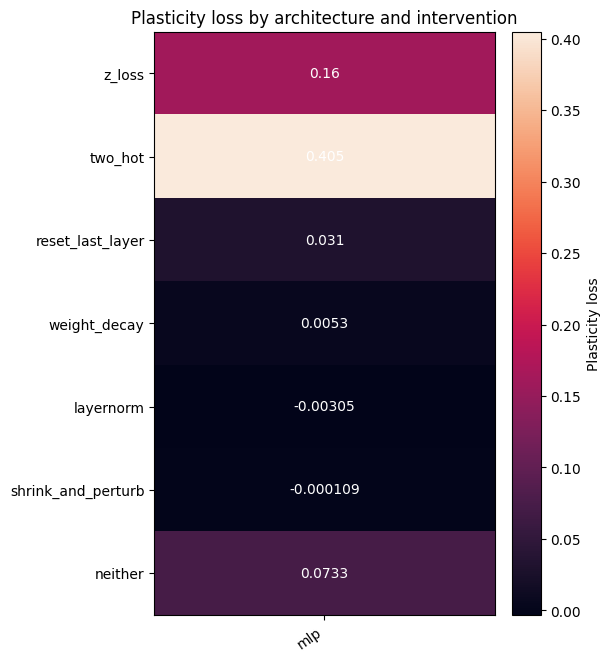

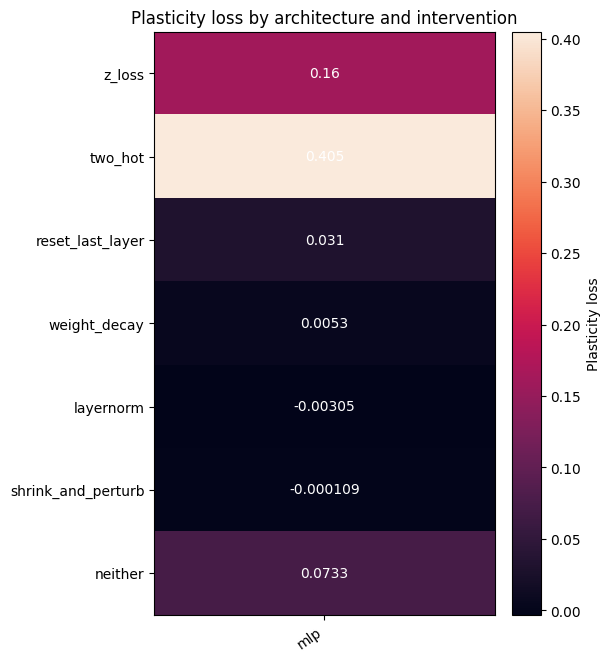

In [37]:
def plot_intervention_matrix(df, save_path=None):
    import matplotlib.pyplot as plt
    import seaborn as sns  # provides the 'rocket' colormap

    matrix = pivot_intervention_matrix(df)
    fig, ax = plt.subplots(figsize=(6.0, 6.5), constrained_layout=True)
    im = ax.imshow(matrix.to_numpy(), cmap=sns.color_palette("rocket", as_cmap=True), aspect="auto")

    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=35, ha="right")
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_title("Plasticity loss by architecture and intervention")

    for row_idx, row_label in enumerate(matrix.index):
        for col_idx, col_label in enumerate(matrix.columns):
            value = matrix.loc[row_label, col_label]
            if pd.notna(value):
                ax.text(col_idx, row_idx, f"{value:.3g}", ha="center", va="center", color="white")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Plasticity loss")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print(f"Saved intervention matrix figure to {save_path}")

    return fig


fig = plot_intervention_matrix(intervention_df, save_path=FIGURES_DIR / "figure6_intervention_matrix.png")
fig